In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
df = sns.load_dataset("mpg")
df = df[['displacement', 'mpg']]
df.dropna(inplace=True)
df.head()

,displacement,mpg
0,307.0,18.0
1,350.0,15.0
2,318.0,18.0
3,304.0,16.0
4,302.0,17.0


In [3]:
X = df['displacement'].values
y = df['mpg'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# ----------FROM SCRATCH----------#
X_train_poly = np.column_stack(
    (np.ones(len(X_train)), X_train, X_train**2)
)

X_test_poly = np.column_stack(
    (np.ones(len(X_test)), X_test, X_test**2)
)

theta = (
    np.linalg.inv(X_train_poly.T @ X_train_poly) @ (X_train_poly.T @ y_train)
)

y_pred = X_test_poly @ theta

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(theta)
print("MSE:", mse)
print("R2:", r2)

[ 4.21989052e+01 -1.38279492e-01  1.67631984e-04]
MSE: 15.107353561081089
R2: 0.7190189176110222


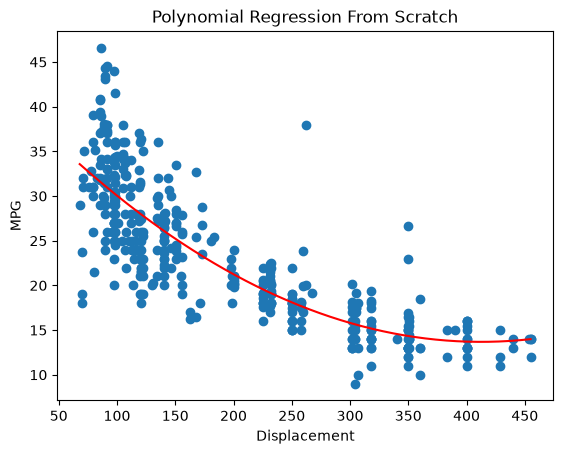

In [5]:
x_line = np.linspace(X.min(), X.max(), 300)
x_poly = np.column_stack((np.ones(len(x_line)), x_line, x_line**2))
y_line = x_poly @ theta

plt.scatter(X, y)
plt.plot(x_line, y_line, color='red')
plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.title("Polynomial Regression From Scratch")
plt.show()

In [6]:
# ----------BUILT IN----------#
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

poly2 = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

poly2.fit(X_train.reshape(-1, 1), y_train)
y_pred2 = poly2.predict(X_test.reshape(-1, 1))

print("MSE:", mean_squared_error(y_test, y_pred2))
print("R2:", r2_score(y_test, y_pred2))

MSE: 15.10735356108076
R2: 0.7190189176110284
